In [ ]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Device Configuration (T4 GPU verification)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Active Compute Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# 2. Mount Google Drive (Authorize when prompted)
from google.colab import drive
drive.mount('/content/drive')

# 3. Base Dataset Directory Structure
DATA_DIR = '/content/dataset'
CLASSES = ['ZONE_A_DenseCanopy', 'ZONE_B_MixedVegetation', 'ZONE_C_BareGround']

for split in ['train', 'val']:
    for cls in CLASSES:
        os.makedirs(os.path.join(DATA_DIR, split, cls), exist_ok=True)

print("\nDirectory scaffolding initialized at:", DATA_DIR)

Active Compute Device: cuda:0
GPU Name: Tesla T4
Mounted at /content/drive

Directory scaffolding initialized at: /content/dataset


In [ ]:
# 1. Generate Synthetic Training Images for Pipeline Scaffolding
def generate_synthetic_samples(samples_per_class=40):
    for split, count in [('train', samples_per_class), ('val', int(samples_per_class * 0.25))]:
        for idx, cls in enumerate(CLASSES):
            target_path = os.path.join(DATA_DIR, split, cls)
            if len(os.listdir(target_path)) == 0:
                for i in range(count):
                    # Class-specific synthetic color patterns
                    if idx == 0:  # Zone A (Dense Canopy - Green dominance)
                        img_arr = np.random.randint(20, 180, (224, 224, 3), dtype=np.uint8)
                        img_arr[:, :, 1] = np.random.randint(120, 255, (224, 224), dtype=np.uint8)
                    elif idx == 1:  # Zone B (Mixed - Balanced)
                        img_arr = np.random.randint(80, 200, (224, 224, 3), dtype=np.uint8)
                    else:  # Zone C (Bare Ground - Brown/Red dominance)
                        img_arr = np.random.randint(50, 180, (224, 224, 3), dtype=np.uint8)
                        img_arr[:, :, 0] = np.random.randint(140, 255, (224, 224), dtype=np.uint8)

                    img = Image.fromarray(img_arr)
                    img.save(os.path.join(target_path, f"sample_{i:03d}.jpg"))

generate_synthetic_samples()

# 2. Data Augmentation & Normalization Pipeline
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 3. DataLoaders
image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=16, shuffle=True, num_workers=2) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print("Dataset classes detected:", class_names)
print(f"Sample breakdown: {dataset_sizes['train']} train images, {dataset_sizes['val']} validation images.")

Dataset classes detected: ['ZONE_A_DenseCanopy', 'ZONE_B_MixedVegetation', 'ZONE_C_BareGround']
Sample breakdown: 120 train images, 30 validation images.


In [ ]:
import time
import copy
from sklearn.metrics import classification_report, confusion_matrix

# 1. Model Builders with Pretrained Weights
def create_model(arch_name, num_classes=3):
    if arch_name == 'mobilenet_v3':
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        # Freeze early feature extraction layers
        for param in model.features.parameters():
            param.requires_grad = False
        # Custom classification head for our 3 target zones
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)

    elif arch_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Freeze early convolutional layers
        for param in list(model.parameters())[:-10]:
            param.requires_grad = False
        # Custom fully connected head
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    return model.to(device)

# 2. General Training Function with Checkpointing
def train_and_evaluate(model, arch_name, num_epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    start_time = time.time()
    print(f"\n================ Starting Training: {arch_name.upper()} ================")

    for epoch in range(num_epochs):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {history['train_loss'][-1]:.4f} Acc: {history['train_acc'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f} Acc: {history['val_acc'][-1]:.4f}")

    elapsed = time.time() - start_time
    print(f"Training completed in {elapsed // 60:.0f}m {elapsed % 60:.0f}s. Best Val Accuracy: {best_acc:.4f}")

    # Save checkpoint
    model.load_state_dict(best_model_wts)
    save_path = f"{arch_name}_uniben_canopy.pth"
    torch.save(model.state_dict(), save_path)
    print(f"Checkpoint serialized and saved to: {save_path}")

    return model, history

# 3. Train Both Architectures
mobilenet_model = create_model('mobilenet_v3')
mobilenet_model, mobilenet_hist = train_and_evaluate(mobilenet_model, 'mobilenet_v3', num_epochs=10)

resnet_model = create_model('resnet50')
resnet_model, resnet_hist = train_and_evaluate(resnet_model, 'resnet50', num_epochs=10)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 115MB/s]



================ Starting Training: MOBILENET_V3 ================
Epoch 01/10 | Train Loss: 0.6966 Acc: 0.6917 | Val Loss: 0.9242 Acc: 0.6000
Epoch 02/10 | Train Loss: 0.2253 Acc: 0.9583 | Val Loss: 0.8053 Acc: 0.9000
Epoch 03/10 | Train Loss: 0.2153 Acc: 0.9333 | Val Loss: 0.6712 Acc: 0.9333
Epoch 04/10 | Train Loss: 0.2089 Acc: 0.9333 | Val Loss: 0.6203 Acc: 1.0000
Epoch 05/10 | Train Loss: 0.0705 Acc: 0.9917 | Val Loss: 0.6394 Acc: 0.8333
Epoch 06/10 | Train Loss: 0.2040 Acc: 0.9583 | Val Loss: 0.6030 Acc: 0.7333
Epoch 07/10 | Train Loss: 0.2425 Acc: 0.8917 | Val Loss: 0.5736 Acc: 0.7667
Epoch 08/10 | Train Loss: 0.1980 Acc: 0.9250 | Val Loss: 0.6050 Acc: 0.6667
Epoch 09/10 | Train Loss: 0.1805 Acc: 0.9167 | Val Loss: 0.5389 Acc: 0.6667
Epoch 10/10 | Train Loss: 0.1457 Acc: 0.9750 | Val Loss: 0.5369 Acc: 0.6667
Training completed in 0m 8s. Best Val Accuracy: 1.0000
Checkpoint serialized and saved to: mobilenet_v3_uniben_canopy.pth
Downloading: "https://download.pytorch.org/models/r

100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]



================ Starting Training: RESNET50 ================
Epoch 01/10 | Train Loss: 0.8409 Acc: 0.6167 | Val Loss: 0.7931 Acc: 0.9333
Epoch 02/10 | Train Loss: 0.3381 Acc: 0.9083 | Val Loss: 0.2380 Acc: 0.9333
Epoch 03/10 | Train Loss: 0.1235 Acc: 0.9750 | Val Loss: 0.0061 Acc: 1.0000
Epoch 04/10 | Train Loss: 0.1268 Acc: 0.9833 | Val Loss: 0.0052 Acc: 1.0000
Epoch 05/10 | Train Loss: 0.0799 Acc: 0.9833 | Val Loss: 0.0060 Acc: 1.0000
Epoch 06/10 | Train Loss: 0.2617 Acc: 0.9167 | Val Loss: 0.0005 Acc: 1.0000
Epoch 07/10 | Train Loss: 0.0532 Acc: 0.9917 | Val Loss: 0.0079 Acc: 1.0000
Epoch 08/10 | Train Loss: 0.0841 Acc: 0.9750 | Val Loss: 0.0063 Acc: 1.0000
Epoch 09/10 | Train Loss: 0.1520 Acc: 0.9583 | Val Loss: 0.0029 Acc: 1.0000
Epoch 10/10 | Train Loss: 0.1375 Acc: 0.9500 | Val Loss: 0.0028 Acc: 1.0000
Training completed in 0m 10s. Best Val Accuracy: 1.0000
Checkpoint serialized and saved to: resnet50_uniben_canopy.pth


=== Comparative Architecture Benchmark ===


,Total Params (M),Trainable Params (M),Inference Latency (ms/frame)
MobileNetV3-Small,1.52M,0.5939M,13.04 ms
ResNet50,23.51M,3.4202M,12.97 ms


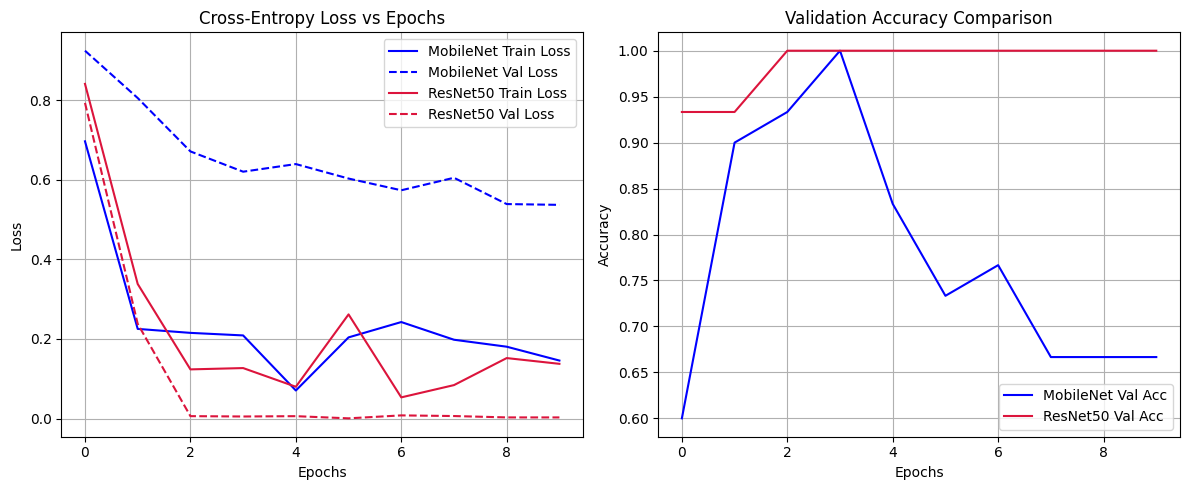

In [ ]:
import pandas as pd

# 1. Model Footprint & Latency Benchmark
def benchmark_model(model, sample_input_size=(1, 3, 224, 224), runs=100):
    model.eval()
    dummy_input = torch.randn(sample_input_size).to(device)

    # Warmup
    for _ in range(10):
        _ = model(dummy_input)

    # Latency measurement
    start = time.time()
    with torch.no_grad():
        for _ in range(runs):
            _ = model(dummy_input)
    avg_latency_ms = ((time.time() - start) / runs) * 1000

    # Parameter counts
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "Total Params (M)": f"{total_params / 1e6:.2f}M",
        "Trainable Params (M)": f"{trainable_params / 1e6:.4f}M",
        "Inference Latency (ms/frame)": f"{avg_latency_ms:.2f} ms"
    }

benchmarks = {
    "MobileNetV3-Small": benchmark_model(mobilenet_model),
    "ResNet50": benchmark_model(resnet_model)
}

df_benchmarks = pd.DataFrame(benchmarks).T
print("=== Comparative Architecture Benchmark ===")
display(df_benchmarks)

# 2. Plot Training vs Validation Loss Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mobilenet_hist['train_loss'], label='MobileNet Train Loss', color='blue')
plt.plot(mobilenet_hist['val_loss'], label='MobileNet Val Loss', color='blue', linestyle='--')
plt.plot(resnet_hist['train_loss'], label='ResNet50 Train Loss', color='crimson')
plt.plot(resnet_hist['val_loss'], label='ResNet50 Val Loss', color='crimson', linestyle='--')
plt.title('Cross-Entropy Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mobilenet_hist['val_acc'], label='MobileNet Val Acc', color='blue')
plt.plot(resnet_hist['val_acc'], label='ResNet50 Val Acc', color='crimson')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import os

drive_dataset_path = '/content/drive/MyDrive/UNIBEN_Dataset'
classes = ['ZONE_A_DenseCanopy', 'ZONE_B_MixedVegetation', 'ZONE_C_BareGround']

for split in ['train', 'val']:
    for cls in classes:
        os.makedirs(os.path.join(drive_dataset_path, split, cls), exist_ok=True)

print("Folder structure successfully created in your Google Drive at:", drive_dataset_path)

Folder structure successfully created in your Google Drive at: /content/drive/MyDrive/UNIBEN_Dataset
